In [2]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [3]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, use_bn=False):
        super().__init__()

        if use_bn:
            self.block = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
        else:
            self.block = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, use_bn=False):
        super(UNet, self).__init__()

        self.enc1 = DoubleConv(in_channels, 64, use_bn)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128, use_bn)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256, use_bn)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(256, 512, use_bn)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024, use_bn)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512, use_bn)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256, use_bn)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128, use_bn)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64, use_bn)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b = self.bottleneck(self.pool4(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [5]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [6]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        self.model = UNet().to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).squeeze(1).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).squeeze(1).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                img_show = img.permute(1, 2, 0).cpu().numpy()
                img_show = (img_show * 0.5 + 0.5).clip(0, 1)

                axes[i, 0].imshow(img_show)
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

                for j in range(3):
                    axes[i, j].axis("off")

            plt.tight_layout()
            plt.show()

In [7]:
trainer = Trainer(config)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 792M/792M [00:23<00:00, 33.1MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 19.3MB/s]


In [8]:
trainer.run()

100%|██████████| 23/23 [00:11<00:00,  1.99it/s]


Epoch 1 / 15, Train Loss: 0.6079, Val Loss: 0.5502, Val IoU: 0.5501, Val F1-score: 0.7068


100%|██████████| 23/23 [00:11<00:00,  2.01it/s]


Epoch 2 / 15, Train Loss: 0.4824, Val Loss: 0.4652, Val IoU: 0.7043, Val F1-score: 0.8216


100%|██████████| 23/23 [00:11<00:00,  1.96it/s]


...

Epoch 14 / 15, Train Loss: 0.2801, Val Loss: 0.2844, Val IoU: 0.8338, Val F1-score: 0.9034


100%|██████████| 23/23 [00:11<00:00,  1.97it/s]


Epoch 15 / 15, Train Loss: 0.2697, Val Loss: 0.2877, Val IoU: 0.8207, Val F1-score: 0.8959
Testing...


100%|██████████| 115/115 [00:59<00:00,  1.92it/s]

Test Loss: 0.2829, Test IoU: 0.8257, Test F1-score: 0.8986


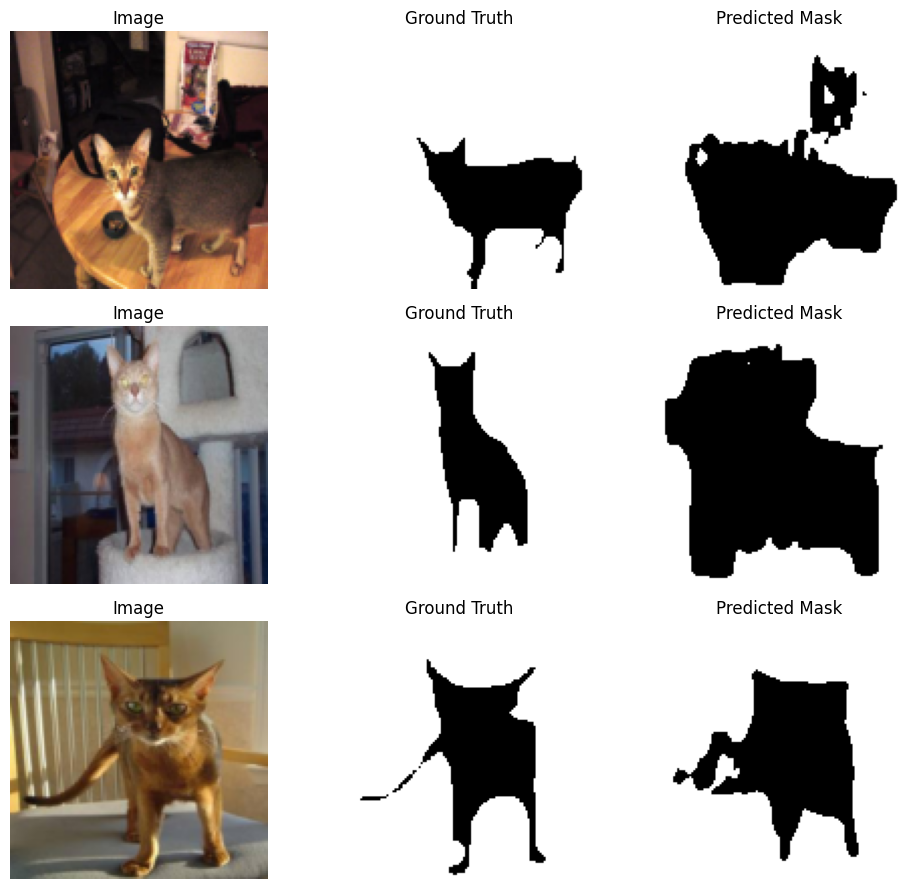

In [9]:
trainer.inference_and_plot_samples(n_samples=3)

In [10]:
import copy
import pandas as pd


In [11]:
class ExperimentTrainer(Trainer):
    def __init__(self, config, use_bn=False):
        self.config = config
        self.use_bn = use_bn

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        self.model = UNet(use_bn=use_bn).to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.train_losses = []
        self.val_losses = []
        self.val_ious = []
        self.val_f1s = []

        self.setup_dataloader()

    def run(self):
        best_model_state = None
        best_val_iou = -1

        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.val_ious.append(val_iou)
            self.val_f1s.append(val_f1)

            if val_iou > best_val_iou:
                best_val_iou = val_iou
                best_model_state = copy.deepcopy(self.model.state_dict())

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

        return {
            "train_losses": self.train_losses,
            "val_losses": self.val_losses,
            "val_ious": self.val_ious,
            "val_f1s": self.val_f1s,
            "test_loss": test_loss,
            "test_iou": test_iou,
            "test_f1": test_f1
        }

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 23/23 [00:11<00:00,  1.93it/s]


Epoch 1 / 15, Train Loss: 0.6055, Val Loss: 0.4800, Val IoU: 0.7380, Val F1-score: 0.8432


100%|██████████| 23/23 [00:11<00:00,  1.92it/s]


Epoch 2 / 15, Train Loss: 0.4750, Val Loss: 0.4435, Val IoU: 0.7585, Val F1-score: 0.8555


100%|██████████| 23/23 [00:12<00:00,  1.91it/s]


...

Epoch 14 / 15, Train Loss: 0.2711, Val Loss: 0.2700, Val IoU: 0.8460, Val F1-score: 0.9116


100%|██████████| 23/23 [00:12<00:00,  1.91it/s]


Epoch 15 / 15, Train Loss: 0.2539, Val Loss: 0.2541, Val IoU: 0.8507, Val F1-score: 0.9147
Testing...


100%|██████████| 115/115 [00:59<00:00,  1.92it/s]


Test Loss: 0.2575, Test IoU: 0.8474, Test F1-score: 0.9118


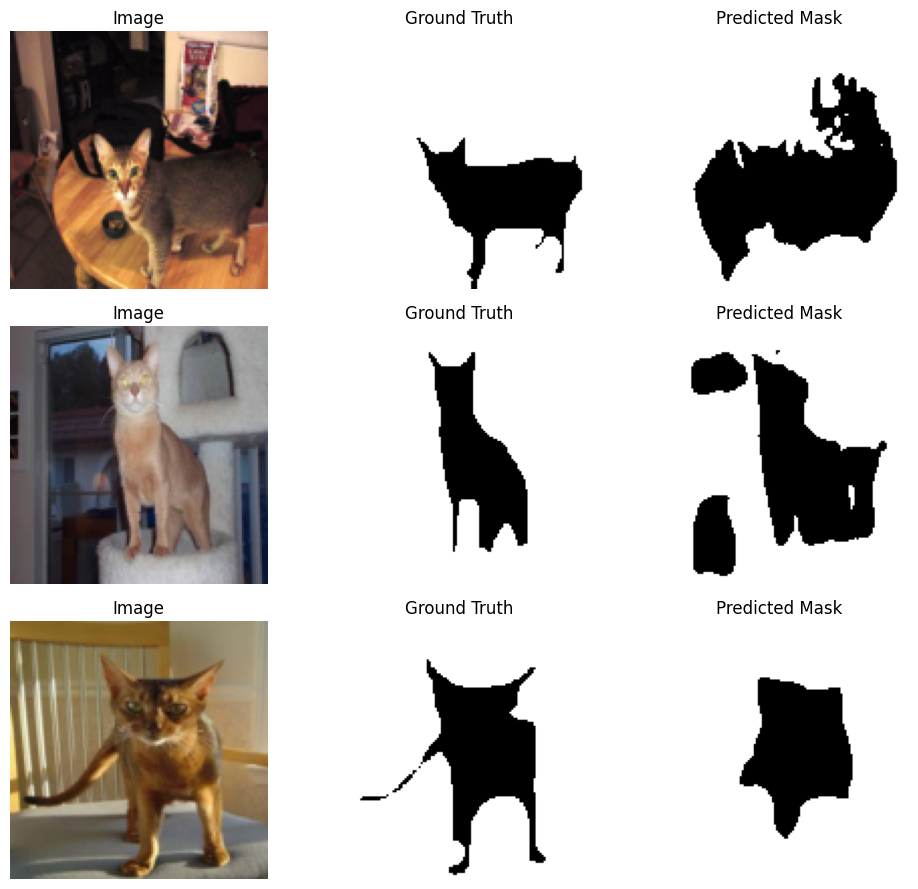

In [12]:
exp_trainer = ExperimentTrainer(config)
base_result = exp_trainer.run()
exp_trainer.inference_and_plot_samples(n_samples=3)

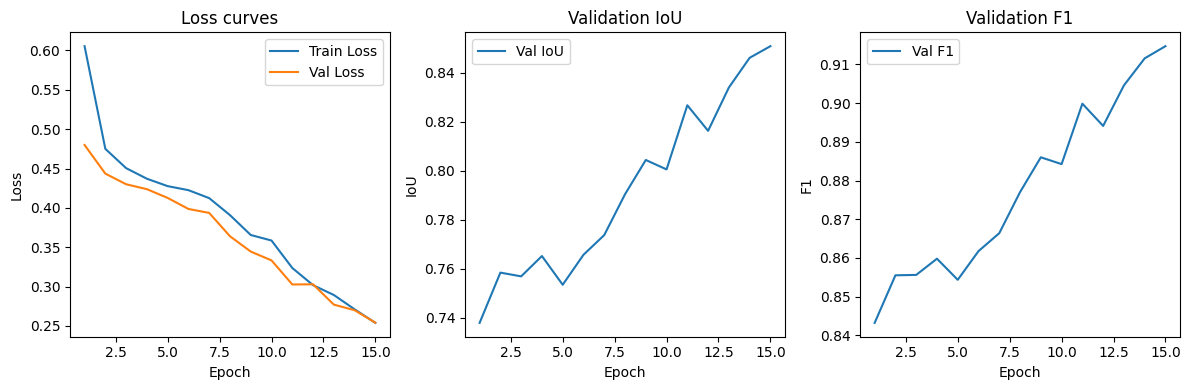

In [13]:
epochs = range(1, len(base_result["train_losses"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, base_result["train_losses"], label="Train Loss")
plt.plot(epochs, base_result["val_losses"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, base_result["val_ious"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Validation IoU")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, base_result["val_f1s"], label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Validation F1")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
learning_rates = [1e-3, 1e-4, 1e-5]
batch_sizes = [16, 32, 64]

search_results = []

for lr in learning_rates:
    for batch_size in batch_sizes:
        exp_config = Config()
        exp_config.learning_rate = lr
        exp_config.batch_size = batch_size
        exp_config.epochs = 6

        print(f"Running: lr={lr}, batch_size={batch_size}")
        trainer = ExperimentTrainer(exp_config)
        result = trainer.run()

        search_results.append({
            "learning_rate": lr,
            "batch_size": batch_size,
            "best_val_iou": max(result["val_ious"]),
            "best_val_f1": max(result["val_f1s"]),
            "test_iou": result["test_iou"],
            "test_f1": result["test_f1"]
        })

Running: lr=0.001, batch_size=16


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:12<00:00,  3.70it/s]


Epoch 1 / 6, Train Loss: 0.6102, Val Loss: 0.5678, Val IoU: 0.7067, Val F1-score: 0.8171


100%|██████████| 46/46 [00:12<00:00,  3.69it/s]


Epoch 2 / 6, Train Loss: 0.4720, Val Loss: 0.4394, Val IoU: 0.7367, Val F1-score: 0.8439


...

Epoch 5 / 6, Train Loss: 0.5125, Val Loss: 0.5031, Val IoU: 0.7046, Val F1-score: 0.8152


100%|██████████| 12/12 [00:12<00:00,  1.04s/it]


Epoch 6 / 6, Train Loss: 0.4998, Val Loss: 0.4931, Val IoU: 0.7341, Val F1-score: 0.8407
Testing...


100%|██████████| 58/58 [01:03<00:00,  1.10s/it]

Test Loss: 0.4927, Test IoU: 0.7304, Test F1-score: 0.8373


In [15]:
search_df = pd.DataFrame(search_results).sort_values("best_val_iou", ascending=False)
print(search_df.to_string(index=False))

 learning_rate  batch_size  best_val_iou  best_val_f1  test_iou  test_f1
       0.00100          32      0.823230     0.898866  0.816276 0.892674
       0.00010          16      0.819279     0.894610  0.826777 0.898640
       0.00100          16      0.804321     0.885826  0.799482 0.881254
       0.00010          64      0.772560     0.864741  0.774232 0.864434
       0.00100          64      0.772080     0.863514  0.768424 0.860073
       0.00010          32      0.762566     0.856833  0.766680 0.859529
       0.00001          32      0.744317     0.846222  0.740187 0.842595
       0.00001          16      0.740575     0.844886  0.746824 0.846010
       0.00001          64      0.734058     0.840674  0.730441 0.837307


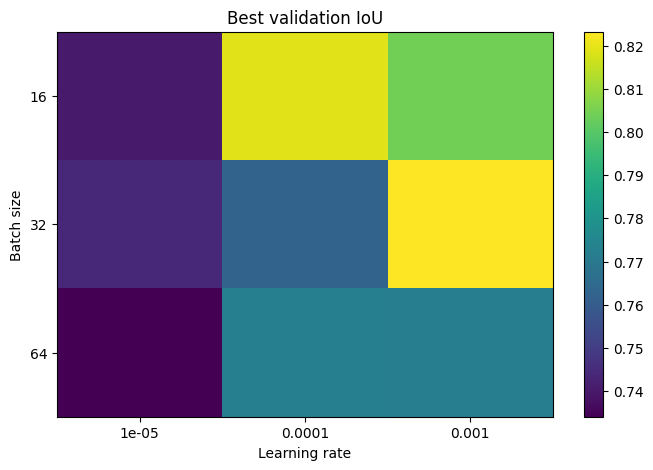

In [16]:
pivot_iou = search_df.pivot(index="batch_size", columns="learning_rate", values="best_val_iou")

plt.figure(figsize=(8, 5))
plt.imshow(pivot_iou, cmap="viridis", aspect="auto")
plt.xticks(range(len(pivot_iou.columns)), [str(x) for x in pivot_iou.columns])
plt.yticks(range(len(pivot_iou.index)), [str(x) for x in pivot_iou.index])
plt.xlabel("Learning rate")
plt.ylabel("Batch size")
plt.title("Best validation IoU")
plt.colorbar()
plt.show()

In [17]:
best_row = search_df.iloc[0]

best_config = Config()
best_config.learning_rate = float(best_row["learning_rate"])
best_config.batch_size = int(best_row["batch_size"])
best_config.epochs = 10

base_trainer = ExperimentTrainer(best_config, use_bn=False)
base_bn_free_result = base_trainer.run()

bn_trainer = ExperimentTrainer(best_config, use_bn=True)
bn_result = bn_trainer.run()

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 23/23 [00:12<00:00,  1.89it/s]


Epoch 1 / 10, Train Loss: 0.5444, Val Loss: 0.4465, Val IoU: 0.7591, Val F1-score: 0.8562


100%|██████████| 23/23 [00:12<00:00,  1.88it/s]


Epoch 2 / 10, Train Loss: 0.4429, Val Loss: 0.4351, Val IoU: 0.7607, Val F1-score: 0.8562


100%|██████████| 23/23 [00:12<00:00,  1.86it/s]


...

Epoch 9 / 10, Train Loss: 0.2011, Val Loss: 0.2020, Val IoU: 0.8807, Val F1-score: 0.9330


100%|██████████| 23/23 [00:12<00:00,  1.90it/s]


Epoch 10 / 10, Train Loss: 0.1896, Val Loss: 0.2069, Val IoU: 0.8804, Val F1-score: 0.9330
Testing...


100%|██████████| 115/115 [01:02<00:00,  1.83it/s]

Test Loss: 0.2131, Test IoU: 0.8729, Test F1-score: 0.9274


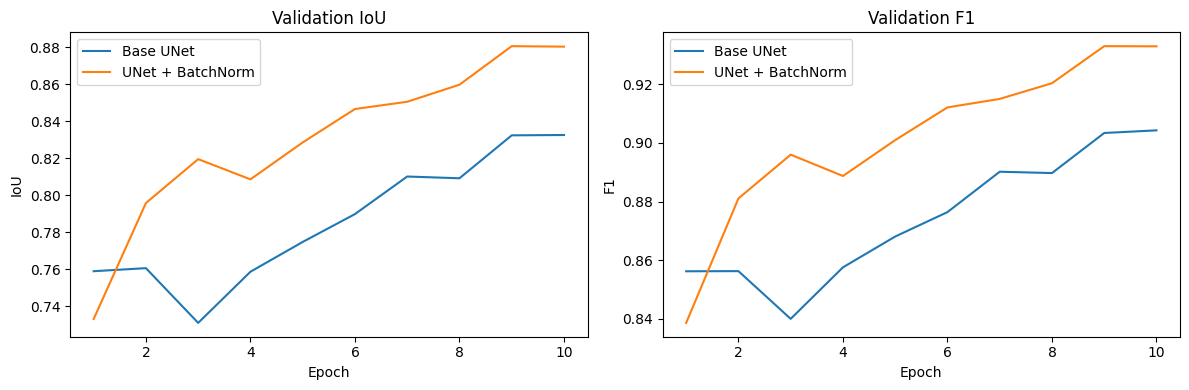

In [18]:
epochs_base = range(1, len(base_bn_free_result["val_ious"]) + 1)
epochs_bn = range(1, len(bn_result["val_ious"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_base, base_bn_free_result["val_ious"], label="Base UNet")
plt.plot(epochs_bn, bn_result["val_ious"], label="UNet + BatchNorm")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Validation IoU")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_base, base_bn_free_result["val_f1s"], label="Base UNet")
plt.plot(epochs_bn, bn_result["val_f1s"], label="UNet + BatchNorm")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Validation F1")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
comparison_df = pd.DataFrame([
    {
        "model": "base_unet",
        "test_iou": base_bn_free_result["test_iou"],
        "test_f1": base_bn_free_result["test_f1"]
    },
    {
        "model": "unet_batchnorm",
        "test_iou": bn_result["test_iou"],
        "test_f1": bn_result["test_f1"]
    }
])

print(comparison_df.to_string(index=False))

         model  test_iou  test_f1
     base_unet  0.831258 0.901961
unet_batchnorm  0.872890 0.927376


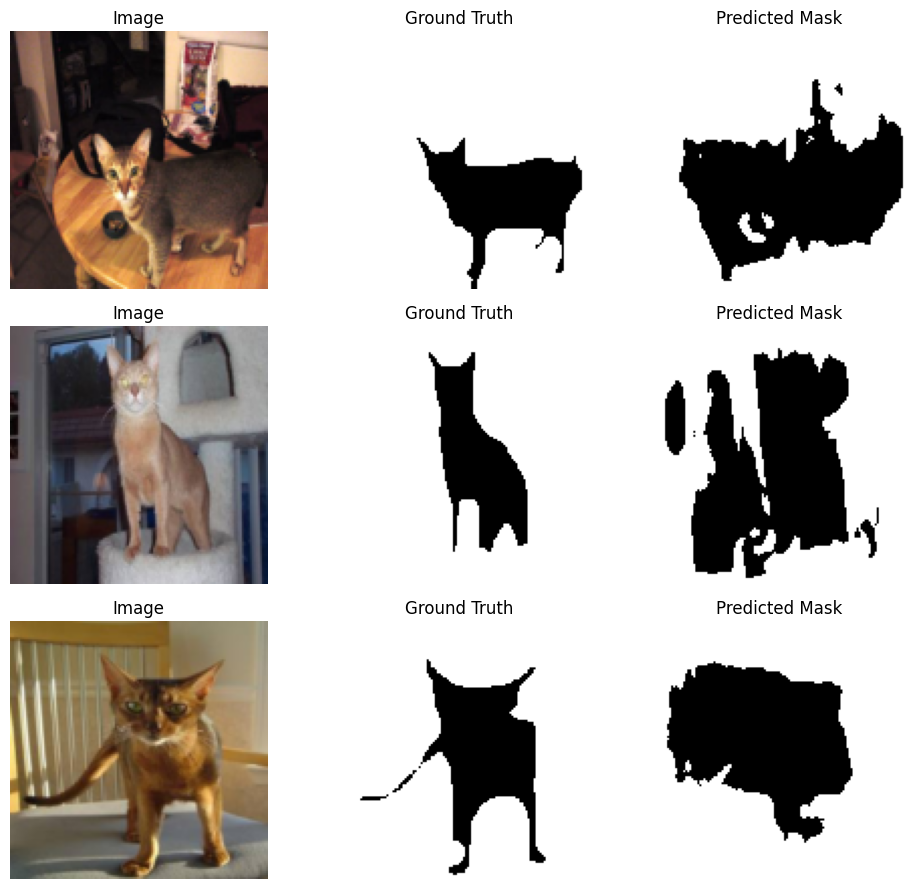

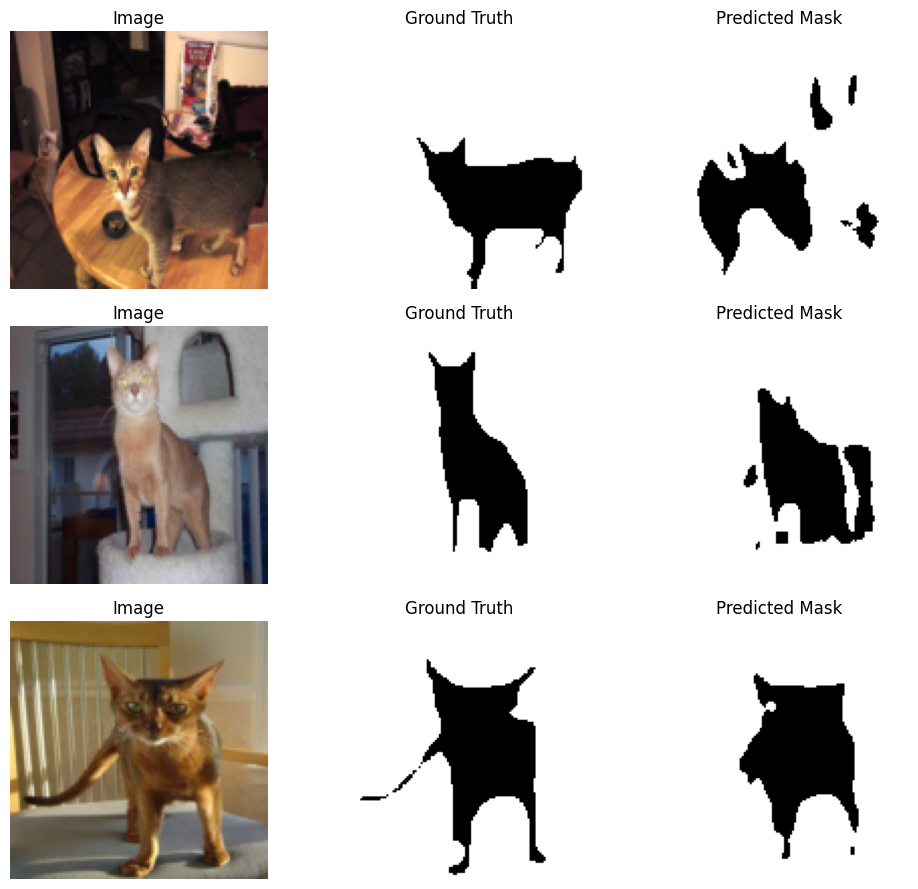

In [20]:
base_trainer.inference_and_plot_samples(n_samples=3)
bn_trainer.inference_and_plot_samples(n_samples=3)